##### Note before getting started: to retreive the most up-to-date data from the NASA exoplanet archive (NEA), install the PyVo package. If you don't that is fine, the code will just import a data file downloaded from the NEA on 24 AUG 2026.

In [1]:
import sys
import os
sys.path.insert(1, os.path.abspath('../general_functions'))
sys.path.insert(0, os.path.abspath('./functions'))

import matplotlib.pyplot as plt
import numpy as np
from functions import *
import pandas as pd
import matplotlib
from matplotlib.ticker import MultipleLocator

try:
    import pyvo as vo
    service = vo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")
    resultset = service.search("SELECT hostname,pl_name,pl_rade,pl_radeerr1,pl_radeerr2,pl_masse,pl_masseerr1,pl_masseerr2,pl_radelim,pl_masselim,pl_orbper,pl_controv_flag,default_flag,discoverymethod,disc_year from ps")
    data = pd.DataFrame({'hostname': resultset['hostname'], 
                             'pl_name': resultset['pl_name'], 
                             'pl_bmasse': resultset['pl_masse'],
                             'pl_bmasseerr1': resultset['pl_masseerr1'],
                             'pl_bmasseerr2': resultset['pl_masseerr2'],
                             'pl_bmasselim': resultset['pl_masselim'],
                             'pl_rade': resultset['pl_rade'],
                             'pl_radeerr1': resultset['pl_radeerr1'],
                             'pl_radeerr2':resultset['pl_radeerr2'],
                             'pl_radelim': resultset['pl_radelim'],
                             'pl_orbper': resultset['pl_orbper'],
                             'pl_controv_flag': resultset['pl_controv_flag'],
                             'default_flag': resultset['default_flag'],
                             'discoverymethod': resultset['discoverymethod'],
                             'disc_year': resultset['disc_year']})
    pldata = data.loc[data["default_flag"] == 1]   
except:
    fpath = './data/PS_2026.07.24_07.42.56.csv'
    pldata = pd.read_csv(fpath)


from nb_toc import toc, back_to_toc, setup
setup()

toc([
    "IAU definition of an exoplanet",
    "Exoplanets through time",
    "M-R relationships for rocky, neptunian, and jovian worlds"
    "Discussion plots"
    ])

<IPython.core.display.Javascript object>

## [IAU definition of an exoplanet](https://arxiv.org/abs/2203.09520)
![IAU_exoplanet_definition.png](./figures/IAU_exoplanet_definition.png)

## Exoplanets through time
While theories about how exoplanets form and evolve, what types of exoplanets we expect to see, etc., they must be "ground-truthed" in observations. In other words, our insights about exoplanets are limited by what we have observed. The animation below shows how the regions of parameter spaces of a few key exoplanet parameters have changed over the last $\sim2.5$ decades, and, in turn, increased our insights into exoplanets and where our own system sits in the broader context. 

With your class mates, discuss what types of planets were first discovered, why, and whether we have an Solar System analogues. What types of planets are we able to probe now that we couldn't in the early 2000s? What regions of the shown parameter spaces have we not yet explored? 

$\textit{Side note}$: If you want a static version of the animation, create a new code cell and call plot_year(pldata, year) and replace the required "year" parameter with the desired year. Additionally, the source code for the animation is "animate_through_time" is in ./functions/functions.py if you want to modify anything.

![through_time.gif](./figures/through_time.gif)

## M-R relationships for rocky, neptunian, and jovian worlds

The plot below shows the CURRENT sample of detected exoplanets with both a mass and radius measurement (so we may calculate density). The lines shows mass-radius (M-R) relationships from [Chen & Kipping 2016](https://iopscience.iop.org/article/10.3847/1538-4357/834/1/17/meta) for three types of planets: Terran (rocky), Neptunian, and Jovian planets. If you are not familiar with M-R relationships, we will be discussing these in detail later in the course. For now, all you need to know is they link a planet's mass and and radius together for an assumed composition (e.g., rocky vs gasy), accounting for how materials react to increasing/decreasing planet mass or size (e.g., a 10M$_\oplus$ Earth-like rocky planet will naturaly be more dense than a 1$M_\oplus$ Earth-like planet). 

With your group (1) try to identify the M-R relationships for rocky, Neptunian, and Jovian planets, (2) discuss the differences/similarities between the M-R relationships, and (3) what may be causing the differences/similarities you observe.

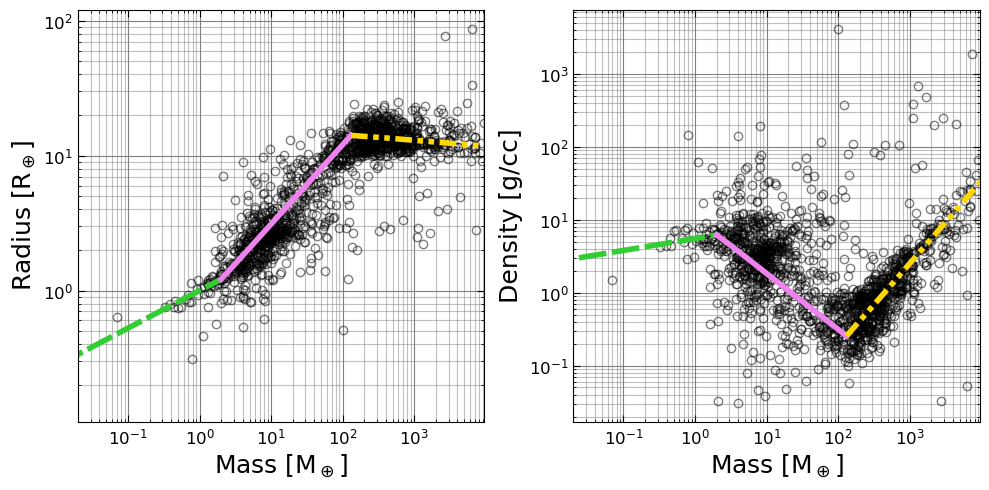

In [16]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
ax[0].plot(pldata['pl_bmasse'], pldata['pl_rade'], 'ko', fillstyle = 'none', alpha = 0.5)
x=np.linspace(min(pldata['pl_bmasse']), max(pldata['pl_bmasse']), 10000)

x1 = np.linspace(0.001, 2.0, 100)
ax[0].plot(x1, 10**chen_kipping(x1), color = 'limegreen', lw = 4, linestyle = (0, (5, 1)))

x2 = np.linspace(2.0, 0.41*318.0, 100)
ax[0].plot(x2, 10**chen_kipping(x2), color = 'violet', lw = 4)

x3 = np.linspace(0.41*318.0, 0.08*333000.0, 100)
ax[0].plot(x3, 10**chen_kipping(x3), color = 'gold', lw = 4, linestyle = (0, (3, 1, 1, 1, 1, 1)))

ax[0].set_yscale('log')
ax[0].set_xscale('log')
ax[0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 12, top = True, right = True)
ax[0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 12, top = True, right = True)
ax[0].grid(visible = True, which = 'major', color= 'gray')
ax[0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)
ax[0].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 18)
ax[0].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 18)
ax[0].set_xlim(min(pldata['pl_bmasse']), max(pldata['pl_bmasse']))


ax[1].plot(pldata['pl_bmasse'], 5.51*pldata['pl_bmasse']/(pldata['pl_rade']**3), 'ko', fillstyle = 'none', alpha = 0.5)

x1 = np.linspace(0.001, 2.0, 100)
ax[1].plot(x1, 5.5*x1/((10**chen_kipping(x1))**3), color = 'limegreen', lw = 4, linestyle = (0, (5, 1)))

x2 = np.linspace(2.0, 0.41*318.0, 100)
ax[1].plot(x2, 5.5*x2/((10**chen_kipping(x2))**3), color = 'violet', lw = 4)

x3 = np.linspace(0.41*318.0, 0.08*333000.0, 100)
ax[1].plot(x3, 5.5*x3/((10**chen_kipping(x3))**3), color = 'gold', lw = 4, linestyle = (0, (3, 1, 1, 1, 1, 1)))


ax[1].set_yscale('log')
ax[1].set_xscale('log')
ax[1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 12, top = True, right = True)
ax[1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 12, top = True, right = True)
ax[1].grid(visible = True, which = 'major', color= 'gray')
ax[1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)
ax[1].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 18)
ax[1].set_ylabel(r'Density [g/cc]', fontsize = 18)
ax[1].set_xlim(min(pldata['pl_bmasse']), max(pldata['pl_bmasse']))

plt.tight_layout()


## Discussion plots

Below are three sets of plots. Each highlights two different flavors of planets. Without any other context, write out a series of observations for each of the figure sets with your group/classmates. Then, try to "interpret" these observations and determine what the various highlighted planets are. Even if you don't have a name for a given type of planet, describe what you think it might look like / be made out of. Where do the Solar System planets fit in each of the sets?


Once you run the code cells below, the figures will be saved in the "figures" directory if you want to view them all side by side. 

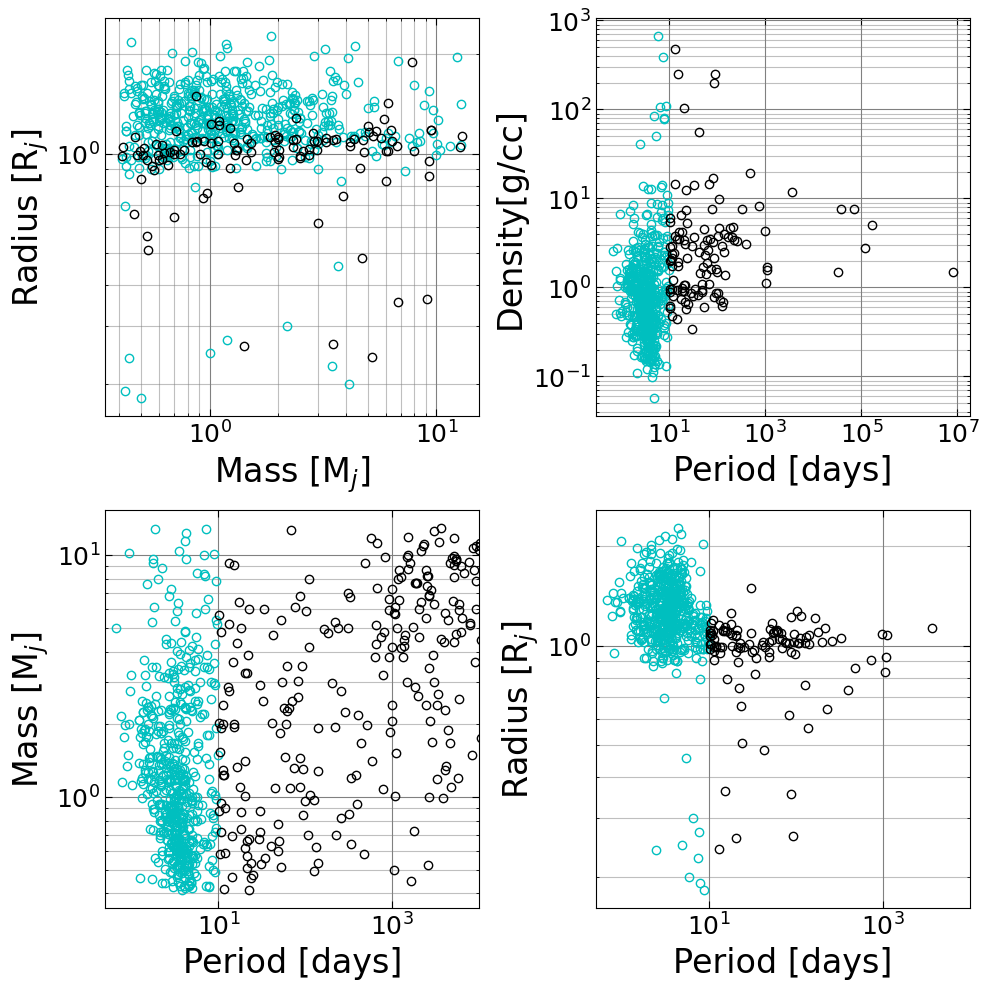

In [17]:
jovian = pldata.iloc[np.where((pldata['pl_bmasse'] >= 0.41*318.0) & (pldata['pl_bmasse']<=13.0*318.0))]
ind1 = np.where(jovian['pl_orbper'] <= 10.0)
ind2 = np.where(jovian['pl_orbper'] > 10.0)

fig, ax = plt.subplots(2, 2, figsize = (10, 10))

ax[1,0].plot(jovian['pl_orbper'].iloc[ind1], jovian['pl_bmasse'].iloc[ind1]/318.0, 'co', fillstyle = 'none')
ax[1,0].plot(jovian['pl_orbper'].iloc[ind2], jovian['pl_bmasse'].iloc[ind2]/318.0, 'ko', fillstyle = 'none')

ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')
#ax[1,0].plot(4333, 1.0, 'ro', markersize = 10, label = 'Jupiter')
ax[1,0].set_xlim(0.5, 10**4)

ax[1,1].plot(jovian['pl_orbper'].iloc[ind1], jovian['pl_rade'].iloc[ind1]/11.0, 'co', fillstyle = 'none')
ax[1,1].plot(jovian['pl_orbper'].iloc[ind2], jovian['pl_rade'].iloc[ind2]/11.0, 'ko', fillstyle = 'none')

ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')
#ax[1,1].plot(4333, 1.0, 'ro', markersize = 10, label = 'Jupiter')
ax[1,1].set_xlim(0.5, 10**4)


ax[0,1].plot(jovian['pl_orbper'].iloc[ind1], 5.51*jovian['pl_bmasse'].iloc[ind1]/(jovian['pl_rade'].iloc[ind1]**3), 'co', fillstyle = 'none')
ax[0,1].plot(jovian['pl_orbper'].iloc[ind2], 5.51*jovian['pl_bmasse'].iloc[ind2]/(jovian['pl_rade'].iloc[ind2]**3), 'ko', fillstyle = 'none')

ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')
#ax[0,1].plot(4333, 1.33, 'ro', markersize = 10, label = 'Jupiter')
#ax[0,1].set_xlim(0.5, 10**4)

ax[1,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 19, top = True, right = True)
ax[1,0].grid(visible = True, which = 'major', color= 'gray')
ax[1,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[1,1].grid(visible = True, which = 'major', color= 'gray')
ax[1,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,1].grid(visible = True, which = 'major', color= 'gray')
ax[0,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,0].plot(jovian['pl_bmasse'].iloc[ind1]/318.0, jovian['pl_rade'].iloc[ind1]/11.0, 'co', fillstyle = 'none')
ax[0,0].plot(jovian['pl_bmasse'].iloc[ind2]/318.0, jovian['pl_rade'].iloc[ind2]/11.0, 'ko', fillstyle = 'none')

ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')
#ax[0,0].plot(1.0, 1.0, 'ro', markersize = 10, label = 'Jupiter')

ax[0,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,0].grid(visible = True, which = 'major', color= 'gray')
ax[0,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)


ax[0,0].set_xlabel(r'Mass [M$_j$]', fontsize = 24)
ax[0,0].set_ylabel(r'Radius [R$_j$]', fontsize = 24)

ax[1,0].set_ylabel(r'Mass [M$_j$]', fontsize = 24)
ax[1,0].set_xlabel(r'Period [days]', fontsize = 24)


ax[1,1].set_ylabel(r'Radius [R$_j$]', fontsize = 24)
ax[1,1].set_xlabel(r'Period [days]', fontsize = 24)


ax[0,1].set_ylabel(r'Density[g/cc]', fontsize = 24)
ax[0,1].set_xlabel(r'Period [days]', fontsize = 24)

plt.tight_layout()
plt.savefig('./figures/exoplanet_mystery_plot_no1.png', dpi = 300)

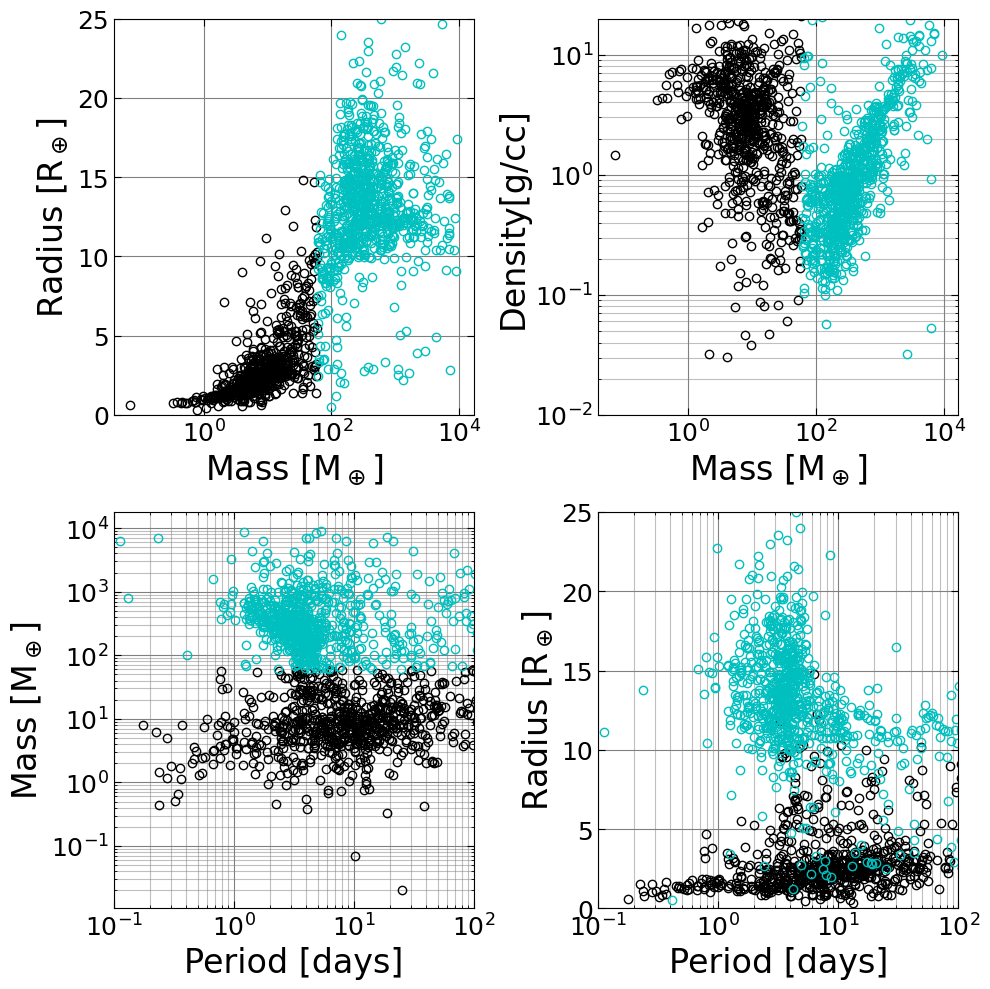

In [18]:
#pldata = pldata.iloc[np.where((pldata['pl_bmasse'] < 0.41*318.0))]
fig, ax = plt.subplots(2, 2, figsize = (10, 10))

mcrit = 60.0
ind1 = np.where(pldata['pl_bmasse'] <= mcrit)
ind2 = np.where(pldata['pl_bmasse'] > mcrit)

alpha = 1.0
ax[1,0].plot(pldata['pl_orbper'].iloc[ind1], pldata['pl_bmasse'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,0].plot(pldata['pl_orbper'].iloc[ind2], pldata['pl_bmasse'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')


ax[1,1].plot(pldata['pl_orbper'].iloc[ind1], pldata['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,1].plot(pldata['pl_orbper'].iloc[ind2], pldata['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

#ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')



ax[0,1].plot(pldata['pl_bmasse'].iloc[ind1], 5.51*pldata['pl_bmasse'].iloc[ind1]/(pldata['pl_rade'].iloc[ind1]**3), 'ko', fillstyle = 'none', alpha = alpha)
ax[0,1].plot(pldata['pl_bmasse'].iloc[ind2], 5.51*pldata['pl_bmasse'].iloc[ind2]/(pldata['pl_rade'].iloc[ind2]**3), 'co', fillstyle = 'none', alpha = alpha)

#ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')



ax[1,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 19, top = True, right = True)
ax[1,0].grid(visible = True, which = 'major', color= 'gray')
ax[1,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[1,1].grid(visible = True, which = 'major', color= 'gray')
ax[1,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,1].grid(visible = True, which = 'major', color= 'gray')
ax[0,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)


ax[1,0].set_ylabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[1,0].set_xlabel(r'Period [days]', fontsize = 24)


ax[1,1].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)
ax[1,1].set_xlabel(r'Period [days]', fontsize = 24)


ax[0,1].set_ylabel(r'Density[g/cc]', fontsize = 24)
ax[0,1].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)

ax[1,1].set_xlim(0.1, 100)
ax[1,0].set_xlim(0.1, 100)
#ax[0,1].set_xlim(0.1, 100)



ax[0,0].plot(pldata['pl_bmasse'].iloc[ind1], pldata['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[0,0].plot(pldata['pl_bmasse'].iloc[ind2], pldata['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)
#ax[0,0].set_yscale('log')
ax[0,0].set_xscale('log')

ax[0,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,0].grid(visible = True, which = 'major', color= 'gray')
ax[0,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)
ax[0,0].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[0,0].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)

ax[0,0].set_ylim(0, 25)
ax[1,1].set_ylim(0, 25)

#ax[1,0].axhline(30.0)
ax[0,1].set_ylim(0.01, 20)
ax[0,1].set_yscale('log')

plt.tight_layout()
plt.savefig('./figures/exoplanet_mystery_plot_no2.png', dpi = 300)

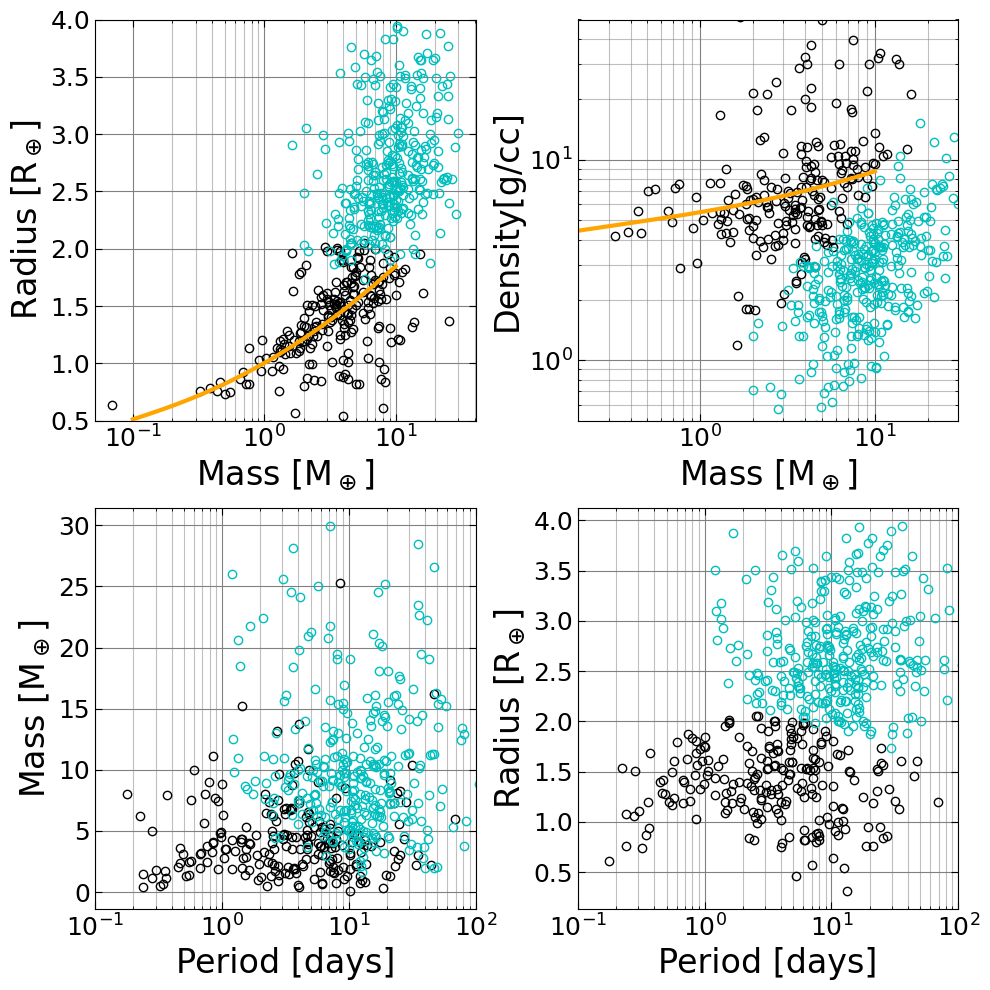

In [20]:
se_sn = pldata.iloc[np.where((pldata['pl_rade'] < 4.0) & (pldata['pl_bmasse']<30))]
#se_sn = se_sn.iloc[np.where((se_sn['pl_radeerr1']/se_sn['pl_rade']) <= 0.3)]
#se_sn = se_sn.iloc[np.where((se_sn['pl_bmasseerr1']/se_sn['pl_bmasse']) <= 0.3)]

fig, ax = plt.subplots(2, 2, figsize = (10, 10))


elike = pd.read_csv('./data/elike.csv')

ind1 = np.where(se_sn['pl_rade'] < 10**(-0.09*np.log10(se_sn['pl_orbper']) + 0.37))
ind2 = np.where(se_sn['pl_rade'] > 10**(-0.09*np.log10(se_sn['pl_orbper']) + 0.37))


alpha = 1.0
ax[1,0].plot(se_sn['pl_orbper'].iloc[ind1], se_sn['pl_bmasse'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,0].plot(se_sn['pl_orbper'].iloc[ind2], se_sn['pl_bmasse'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

#ax[1,0].set_yscale('log')
ax[1,0].set_xscale('log')


ax[1,1].plot(se_sn['pl_orbper'].iloc[ind1], se_sn['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[1,1].plot(se_sn['pl_orbper'].iloc[ind2], se_sn['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)

#ax[1,1].set_yscale('log')
ax[1,1].set_xscale('log')



ax[0,1].plot(se_sn['pl_bmasse'].iloc[ind1], 5.51*se_sn['pl_bmasse'].iloc[ind1]/(se_sn['pl_rade'].iloc[ind1]**3), 'ko', fillstyle = 'none', alpha = alpha)
ax[0,1].plot(se_sn['pl_bmasse'].iloc[ind2], 5.51*se_sn['pl_bmasse'].iloc[ind2]/(se_sn['pl_rade'].iloc[ind2]**3), 'co', fillstyle = 'none', alpha = alpha)

ax[0,1].set_yscale('log')
ax[0,1].set_xscale('log')



ax[1,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 19, top = True, right = True)
ax[1,0].grid(visible = True, which = 'major', color= 'gray')
ax[1,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[1,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[1,1].grid(visible = True, which = 'major', color= 'gray')
ax[1,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,1].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,1].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,1].grid(visible = True, which = 'major', color= 'gray')
ax[0,1].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[0,0].tick_params(which = 'major', direction = 'in', length = 5, labelsize = 18, top = True, right = True)
ax[0,0].tick_params(which = 'minor', direction = 'in', length = 2.5, labelsize = 18, top = True, right = True)
ax[0,0].grid(visible = True, which = 'major', color= 'gray')
ax[0,0].grid(visible = True, which = 'minor', color= 'gray', alpha = 0.5)

ax[1,0].set_ylabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[1,0].set_xlabel(r'Period [days]', fontsize = 24)


ax[1,1].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)
ax[1,1].set_xlabel(r'Period [days]', fontsize = 24)


ax[0,1].set_ylabel(r'Density[g/cc]', fontsize = 24)
ax[0,1].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)

ax[0,0].plot(se_sn['pl_bmasse'].iloc[ind1], se_sn['pl_rade'].iloc[ind1], 'ko', fillstyle = 'none', alpha = alpha)
ax[0,0].plot(se_sn['pl_bmasse'].iloc[ind2], se_sn['pl_rade'].iloc[ind2], 'co', fillstyle = 'none', alpha = alpha)
ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')
ax[0,0].set_xticks([0.1, 1.0, 10.0, 100.0])
ax[0,0].set_xticks( [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 
                     2,3,4,5,6,7,8,9,
                     20.0, 30.0, 40., 50., 60, 70, 80, 90], minor = True)


ax[1,1].set_xlim(0.1, 100)
ax[1,0].set_xlim(0.1, 100)
#ax[0,1].set_xlim(0.1, 100)


ax[0,0].set_xlabel(r'Mass [M$_\oplus$]', fontsize = 24)
ax[0,0].set_ylabel(r'Radius [R$_\oplus$]', fontsize = 24)

ax[0,0].plot(elike['mass'], elike['radius'], '-', color = 'orange', lw = 3)
ax[0,1].plot(elike['mass'], elike['density'], '-', color = 'orange', lw = 3)


ax[0,1].set_ylim(0.5, 50)
ax[0,1].set_xlim(2*(10**(-1)), 30)

ax[0,0].set_ylim(0.5, 4.0)
plt.tight_layout()

plt.savefig('./figures/exoplanet_mystery_plot_no3.png', dpi = 300)